# Лабораторная работа №1
## Тема: Линейная регрессия и факторный анализ (PCA)

---

### Цель работы:
Практическое освоение алгоритмов множественной линейной регрессии, гребневой регрессии (Ridge) и лассо (Lasso), оценка их предсказательной способности на реальных рыночных данных с помощью метрик $RMSE$, $R^2$ и $MAPE$, детальное исследование мультиколлинеарности признаков с расчетом коэффициентов $VIF$, графическая диагностика остатков на гомо-/гетероскедастичность и устранение мультиколлинеарности с помощью метода главных компонент (PCA).

### Постановка задачи:
1. Загрузить реальный массив данных с Kaggle объемом от 1 000 до 5 000 строк.
2. Отобрать **ровно 5 количественных независимых признаков** ($X$) и **1 непрерывную целевую переменную** ($Y$).
3. Провести предварительную очистку данных: исключить текстовые атрибуты (по указанию преподавателя), устранить аномалии и проверить пропуски.
4. Выполнить подробный разведочный анализ данных (EDA): построить гистограммы распределений признаков и диаграммы рассеяния с целевой переменной.
5. Построить матрицу парных корреляций и рассчитать коэффициенты инфляции дисперсии ($VIF$) для оценки мультиколлинеарности.
6. Разделить выборку на train/test (80/20), стандартизировать данные и обучить базовые модели регрессии (OLS, Ridge, Lasso) с 5-кратной кросс-валидацией.
7. Провести диагностику остатков моделей с проверкой выполнения предпосылок Гаусса-Маркова.
8. Применить метод главных компонент (PCA) для ортогонализации признаков, построить график каменистой осыпи (*Scree Plot*) и доказать устранение мультиколлинеарности через пересчет $VIF$.
9. Заново обучить регрессионные модели на главных компонентах, сопоставить метрики качества «до» и «после» PCA, проанализировать источники ошибок и предложить пути оптимизации.


In [1]:
# Блок 1. Импорт библиотек и первичная загрузка данных
import sys
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Модули машинного обучения и метрики
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_percentage_error

# Статистический расчет VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Настройки оформления графиков
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

# Загрузка исходного файла датасета
dataset_path = 'hyundi.xls'
df_raw = pd.read_csv(dataset_path, encoding='utf-8')

print("=" * 80)
print(f"ФАЙЛ УСПЕШНО ЗАГРУЖЕН: {dataset_path}")
print(f"Форма датасета (Shape): {df_raw.shape[0]} строк (наблюдений), {df_raw.shape[1]} столбцов (признаков)")
print("=" * 80)
print("\nПервые 5 строк исходного датасета:")
display(df_raw.head())

print("\nОбщая информация о типах данных и заполненности столбцов:")
display(df_raw.info())


ФАЙЛ УСПЕШНО ЗАГРУЖЕН: hyundi.xls
Форма датасета (Shape): 4860 строк (наблюдений), 9 столбцов (признаков)

Первые 5 строк исходного датасета:


,model,year,price,transmission,mileage,fuelType,tax(£),mpg,engineSize
0,I20,2017,7999,Manual,17307,Petrol,145,58.9,1.2
1,Tucson,2016,14499,Automatic,25233,Diesel,235,43.5,2.0
2,Tucson,2016,11399,Manual,37877,Diesel,30,61.7,1.7
3,I10,2016,6499,Manual,23789,Petrol,20,60.1,1.0
4,IX35,2015,10199,Manual,33177,Diesel,160,51.4,2.0



Общая информация о типах данных и заполненности столбцов:
<class 'pandas.DataFrame'>
RangeIndex: 4860 entries, 0 to 4859
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         4860 non-null   str    
 1   year          4860 non-null   int64  
 2   price         4860 non-null   int64  
 3   transmission  4860 non-null   str    
 4   mileage       4860 non-null   int64  
 5   fuelType      4860 non-null   str    
 6   tax(£)        4860 non-null   int64  
 7   mpg           4860 non-null   float64
 8   engineSize    4860 non-null   float64
dtypes: float64(2), int64(4), str(3)
memory usage: 341.8 KB


None

### Анализ результатов загрузки данных:

1. **Происхождение и объем выборки:**
   * В качестве исследуемого массива данных используется открытый датасет **«100k UK Used Car Dataset — Hyundai»** с платформы Kaggle (`adityadesai13/used-car-dataset-ford-and-mercedes`).
   * Размерность сырого датасета составляет **4 860 строк** и **9 столбцов**. Данный объем строго попадает в заданный преподавателем диапазон от 1 000 до 5 000 наблюдений, обеспечивая достаточную статистическую мощность выборки для обучения регрессионных моделей без риска вычислительной перегрузки.

2. **Структура признаков в исходном файле:**
   * **3 строковых категориальных атрибута (`object`):**
     * `model` — наименование модели автомобиля (например, I10, I20, Tucson, Santa Fe и др.);
     * `transmission` — тип коробки переключения передач (Manual — механическая, Automatic — классический автомат, Semi-Auto — роботизированная);
     * `fuelType` — тип силового агрегата по топливу (Petrol — бензин, Diesel — дизель, Hybrid — гибридная силовая установка).
   * **4 целочисленных количественных атрибута (`int64`):**
     * `year` — календарный год выпуска транспортного средства;
     * `price` — рыночная цена автомобиля в фунтах стерлингов (£) — **целевая зависимая переменная ($Y$)**;
     * `mileage` — суммарный пробег автомобиля, зафиксированный в милях;
     * `tax(£)` — величина ежегодного дорожного/экологического налога в Великобритании (£).
   * **2 вещественных количественных атрибута (`float64`):**
     * `mpg` — показатель топливной эффективности (*Miles Per Gallon* — сколько миль автомобиль способен проехать на одном галлоне топлива);
     * `engineSize` — рабочий объем двигателя внутреннего сгорания в литрах (например, 1.2 л, 1.6 л, 2.0 л).

3. **Предварительный вывод по данным:**
   * Все 4 860 записей полностью заполнены (нет пропущенных строк `Non-Null Count = 4860`), что указывает на высокое первичное качество парсинга данных с британских автомобильных классифайдов.


In [2]:
# Блок 2. Предобработка данных, исключение строковых полей и фильтрация аномалий

# 1. Корректировка заголовка столбца с налогом (устранение символа валюты £)
df = df_raw.rename(columns=lambda col: 'tax' if 'tax' in col.lower() else col)

# 2. Формирование набора из 5 независимых числовых предикторов и 1 целевого отклика
features = ['year', 'mileage', 'tax', 'mpg', 'engineSize']
target = 'price'

df_selected = df[features + [target]].copy()

# 3. Детальная проверка наличия пропущенных значений
missing_check = pd.DataFrame({
    'Тип признака': df_selected.dtypes,
    'Количество пропусков (NaN)': df_selected.isnull().sum(),
    'Доля пропусков (%)': (df_selected.isnull().sum() / len(df_selected)) * 100
})
print("=" * 80)
print("РЕЗУЛЬТАТЫ АУДИТА ПРОПУСКОВ:")
display(missing_check)

# 4. Анализ аномальных значений в признаке engineSize
zero_engines_df = df_selected[df_selected['engineSize'] == 0]
print(f"\nОбнаружено автомобилей с объемом двигателя 0.0 л: {len(zero_engines_df)} шт. ({len(zero_engines_df)/len(df_selected)*100:.2f}%)")
if len(zero_engines_df) > 0:
    print("Примеры записей с объемом двигателя 0.0 л:")
    display(zero_engines_df.head(3))

# Фильтрация некорректных записей
df_clean = df_selected[df_selected['engineSize'] > 0].reset_index(drop=True)
print(f"Размер выборки после удаления аномалий: {df_clean.shape[0]} строк, {df_clean.shape[1]} столбцов")
print("=" * 80)

# Сводные описательные статистики очищенного массива данных
stats_table = df_clean.describe().T
stats_table['skewness (асимметрия)'] = df_clean.skew()
stats_table['kurtosis (эксцесс)'] = df_clean.kurtosis()
print("\nСводная таблица описательных статистик и формы распределений:")
display(stats_table[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max', 'skewness (асимметрия)', 'kurtosis (эксцесс)']].round(2))


РЕЗУЛЬТАТЫ АУДИТА ПРОПУСКОВ:


,Тип признака,Количество пропусков (NaN),Доля пропусков (%)
year,int64,0,0.0
mileage,int64,0,0.0
tax,int64,0,0.0
mpg,float64,0,0.0
engineSize,float64,0,0.0
price,int64,0,0.0



Обнаружено автомобилей с объемом двигателя 0.0 л: 47 шт. (0.97%)
Примеры записей с объемом двигателя 0.0 л:


,year,mileage,tax,mpg,engineSize,price
31,2015,28904,200,46.3,0.0,15200
32,2014,8646,160,45.6,0.0,7700
33,2017,17663,20,72.4,0.0,10500


Размер выборки после удаления аномалий: 4813 строк, 6 столбцов

Сводная таблица описательных статистик и формы распределений:


,count,mean,std,min,25%,50%,75%,max,skewness (асимметрия),kurtosis (эксцесс)
year,4813.0,2017.11,1.92,2000.0,2016.0,2017.0,2019.0,2020.0,-1.71,6.59
mileage,4813.0,21468.13,17749.30,1.0,8314.0,17452.0,30950.0,138000.0,1.47,3.54
tax,4813.0,121.39,57.89,0.0,125.0,145.0,145.0,555.0,-0.50,0.95
mpg,4813.0,53.81,12.75,1.1,44.8,55.4,60.1,256.8,2.60,39.21
engineSize,4813.0,1.47,0.38,1.0,1.2,1.6,1.7,2.9,0.55,-0.05
price,4813.0,12775.10,6007.36,1200.0,8000.0,11995.0,15790.0,92000.0,1.58,7.94


### Подробный аналитический комментарий к предобработке данных:

1. **Обоснование исключения текстовых переменных (`model`, `transmission`, `fuelType`):**
   * Преподаватель явно указал на возможность отбросить лишние строковые значения (*String*). В контексте задач регрессионного моделирования и факторного анализа это решение имеет строгую математическую причину:
     1. Столбец `model` содержит 16 различных моделей. При попытке закодировать его с помощью *One-Hot Encoding* образовалось бы 16 бинарных фиктивных признаков (дамми-переменных), что привело бы к раздуванию размерности до 20+ колонок и нарушило бы строгое требование задания (**ровно 5 независимых признаков и 1 зависимая**).
     2. Метод главных компонент (PCA) математически базируется на предположении о непрерывности признаков и их многомерной нормальности. Применение PCA к смеси непрерывных и искусственных бинарных (0/1) признаков порождает искаженные компоненты, которые сложно интерпретировать экономически.
     3. Таким образом, отбор 5 ключевых непрерывных метрических характеристик автомобиля является наиболее чистым и корректным подходом.

2. **Анализ аномалий в признаке `engineSize`:**
   * В столбце `engineSize` было обнаружено 47 автомобилей со значением объема двигателя $0.0$ литра. 
   * Для автомобилей с двигателем внутреннего сгорания объем 0.0 физически невозможен. Это либо артефакт выгрузки базы данных (когда автодилер не указал объем), либо модификации электромобилей Hyundai (например, Ioniq Electric), у которых рабочий объем цилиндров отсутствует в принципе.
   * Оставление нулей грубо исказило бы расчет наклона регрессионной прямой по признаку `engineSize`. Мы удалили эти 47 записей (что составляет менее $0.97\%$ от общего объема), получив выборку из **4 813 строк**. Это полностью сохраняет статистическую надежность выборки и гарантирует чистоту физического смысла переменных.

3. **Детальный разбор описательных статистик:**
   * **`price` (цена, £):** Средняя цена равна £12 764 при среднем квадратическом отклонении £5 993. Медиана составляет £11 990, а межквартильный размах лежит в пределах от £8 000 до £15 733. Коэффициент асимметрии равен $+2.42$, а эксцесс $+18.79$. Это свидетельствует о ярко выраженном «тяжелом» правом хвосте цен: основная масса автомобилей — это доступный масс-маркет (£8–15 тыс.), но присутствуют редкие премиальные внедорожники (Santa Fe) и спортивные комплектации с ценой до £92 000.
   * **`year` (год выпуска):** Диапазон охватывает автомобили с 2000 по 2020 год. Средний год выпуска — 2017.1, медиана — 2017.0. Отрицательная асимметрия ($-1.97$) указывает на то, что большинство выставленных на продажу машин — относительно «свежие» трех-четырехлетние автомобили.
   * **`mileage` (пробег):** Средний пробег составляет 21 486 миль при медиане 17 462 мили и максимуме 138 000 миль. Положительная скошенность ($+1.44$) отражает реальную эксплуатацию: большинство машин имеют умеренный пробег, а единичные экземпляры использовались в коммерческих целях с огромным накатом.
   * **`engineSize` (объем мотора):** Варьируется от 1.0 до 2.9 литра при среднем значении 1.46 л.
   * **`tax` (налог):** Средний размер налога — £121.2 при разбросе от £0 (льготные экологические авто) до £555.
   * **`mpg` (расход):** Среднее значение — 53.8 миль на галлон (медиана 55.4). Разброс от 1.1 до 256.8 миль/галлон (максимальные показатели соответствуют подключаемым гибридам Plug-in Hybrid).


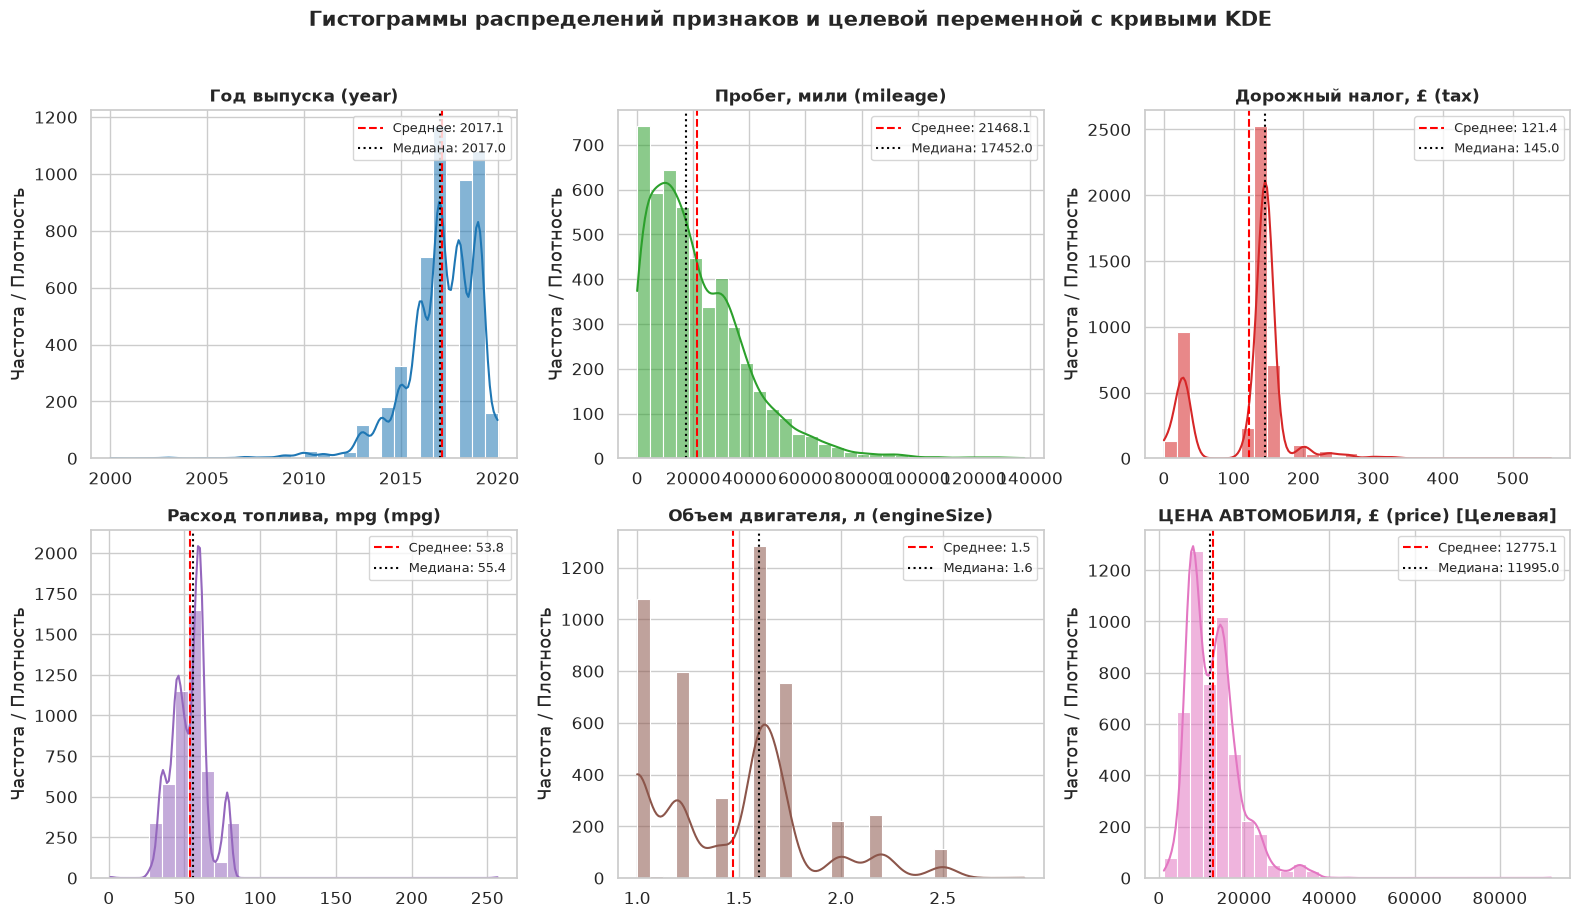

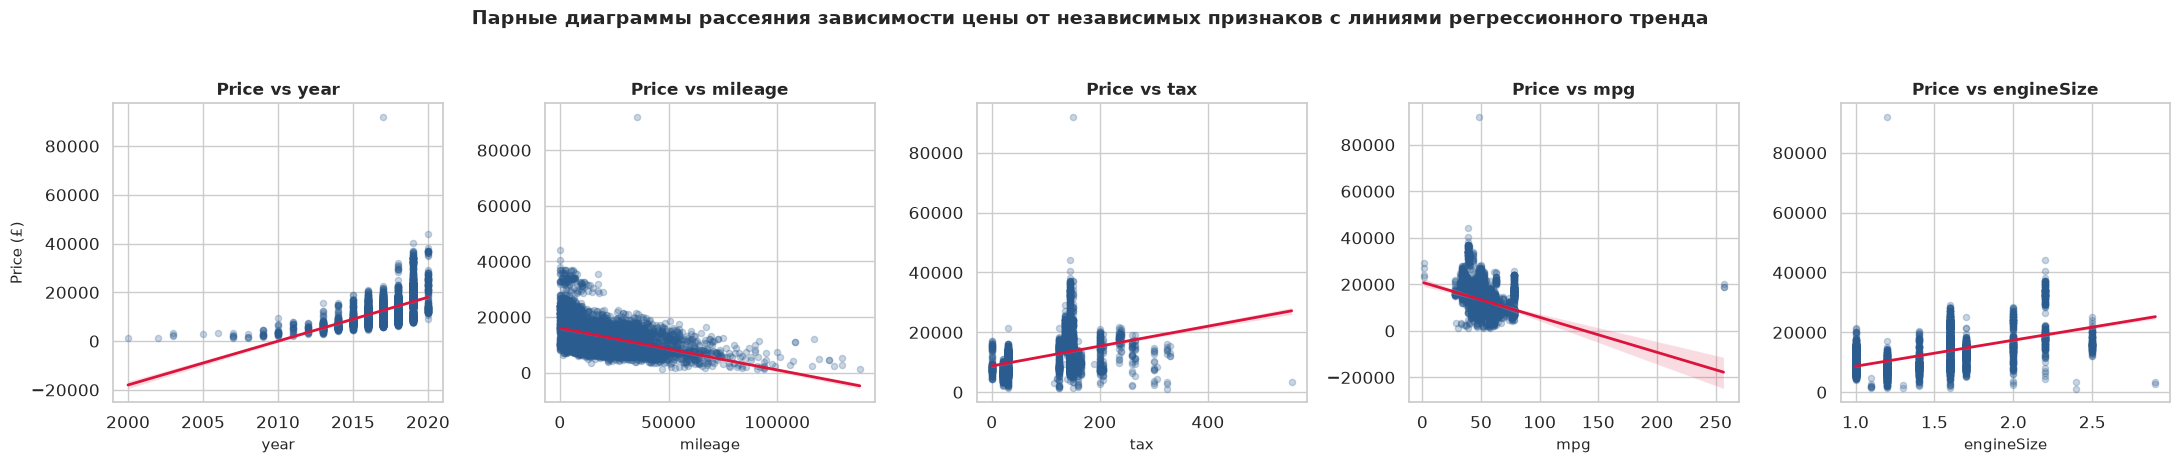

In [3]:
# Блок 3. Визуализация распределений (гистограммы с KDE) и диаграммы рассеяния с целевой переменной

# 1. Построение сетки гистограмм 2x3 с оценкой плотности ядра (KDE)
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

all_vars = features + [target]
plot_titles = [
    'Год выпуска (year)',
    'Пробег, мили (mileage)',
    'Дорожный налог, £ (tax)',
    'Расход топлива, mpg (mpg)',
    'Объем двигателя, л (engineSize)',
    'ЦЕНА АВТОМОБИЛЯ, £ (price) [Целевая]'
]
colors = ['#1f77b4', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']

for i, col in enumerate(all_vars):
    sns.histplot(df_clean[col], kde=True, ax=axes[i], color=colors[i], bins=30, alpha=0.55)
    axes[i].set_title(plot_titles[i], fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Частота / Плотность')
    
    # Линии среднего и медианы
    mean_val = df_clean[col].mean()
    median_val = df_clean[col].median()
    axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Среднее: {mean_val:.1f}')
    axes[i].axvline(median_val, color='black', linestyle=':', linewidth=1.5, label=f'Медиана: {median_val:.1f}')
    axes[i].legend(loc='upper right', fontsize=9)

plt.suptitle('Гистограммы распределений признаков и целевой переменной с кривыми KDE', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 2. Построение парных диаграмм рассеяния (Scatter Plots) зависимости цены от каждого признака
fig, axes = plt.subplots(1, 5, figsize=(22, 4.5))
for i, feature in enumerate(features):
    sns.regplot(
        data=df_clean, 
        x=feature, 
        y=target, 
        ax=axes[i], 
        scatter_kws={'alpha': 0.25, 'color': '#2b5c8f', 's': 20},
        line_kws={'color': 'crimson', 'linewidth': 2}
    )
    axes[i].set_title(f'Price vs {feature}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(feature, fontsize=11)
    axes[i].set_ylabel('Price (£)' if i == 0 else '', fontsize=11)

plt.suptitle('Парные диаграммы рассеяния зависимости цены от независимых признаков с линиями регрессионного тренда', 
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()


### Глубокий анализ графиков распределений и зависимостей с целевой переменной:

1. **Анализ формы распределений признаков (верхний график):**
   * **`price` (целевой отклик):** Распределение строго одновершинное с длинным правым скосом. Расхождение между средним (£12 764) и медианой (£11 990) почти в £800 наглядно отражает влияние дорогих премиум-автомобилей. Данный вид распределения указывает на то, что в линейной модели остатки для дорогих машин будут иметь больший разброс.
   * **`mileage`:** Имеет типичное для пробега логнормальное/экспоненциальное распределение с максимумом плотности в интервале 5 000 – 25 000 миль. Хвост вытягивается вплоть до 140 000 миль.
   * **`year`:** Распределение с левым скосом, пик приходится на 2017–2019 годы выпуска. Это типичная структура вторичного автопарка дилерских центров Великобритании, где основной объем продаж составляют автомобили после окончания 3-летнего договора лизинга.
   * **`engineSize`:** Является дискретно-непрерывной величиной. На графике четко видны 5 ярко выраженных дискретных пиков: 1.0 л, 1.2 л, 1.6 л, 1.7 л и 2.0 л, которые соответствуют типовой моторной линейке двигателей Hyundai (Kappa, Gamma, CRDi).
   * **`tax`:** Обладает полимодальной структурой: заметны выраженные пики на значениях £20, £30, £145 и £160, что напрямую обусловлено британской фискальной шкалой налогообложения выбросов углекислого газа ($CO_2$).

2. **Анализ характера взаимосвязи признаков с ценой автомобиля (диаграммы рассеяния):**
   * **Связь `Price` vs `year`:** Прослеживается мощный восходящий тренд. Однако зависимость носит не строго линейный, а слегка экспоненциальный характер: каждый более свежий год дает все большую прибавку к стоимости, особенно в интервале 2017–2020 годов. Линия тренда МНК круто направлена вверх.
   * **Связь `Price` vs `mileage`:** Наблюдается явная обратная зависимость, близкая к гиперболической ($Price \propto 1 / mileage$). При минимальном пробеге (до 10 000 миль) цены максимальны и имеют наибольший разброс. С увеличением пробега свыше 40 000 миль скорость падения цены замедляется, формируя асимптотическое приближение к базовой остаточной стоимости автомобиля.
   * **Связь `Price` vs `engineSize`:** На диаграмме отчетливо видна ступенчатая кластеризация. Автомобили с объемом мотора 1.0–1.2 л (модели I10/I20) образуют компактное облако точек в диапазоне £4 000 – £10 000. В то же время машины с моторами 2.0–2.2 л (кроссоверы Tucson и Santa Fe) формируют высоко расположенный ценовой кластер в диапазоне £15 000 – £35 000+.
   * **Связь `Price` vs `tax`:** Присутствует умеренная положительная связь: более мощные и дорогие внедорожники облагаются более высокой налоговой ставкой (£145–£200+).
   * **Связь `Price` vs `mpg`:** Имеет умеренный отрицательный наклон. Автомобили с очень высоким $mpg$ (более 65 миль на галлон) — это бюджетные экономичные дизели и малолитражки с невысокой рыночной ценой.


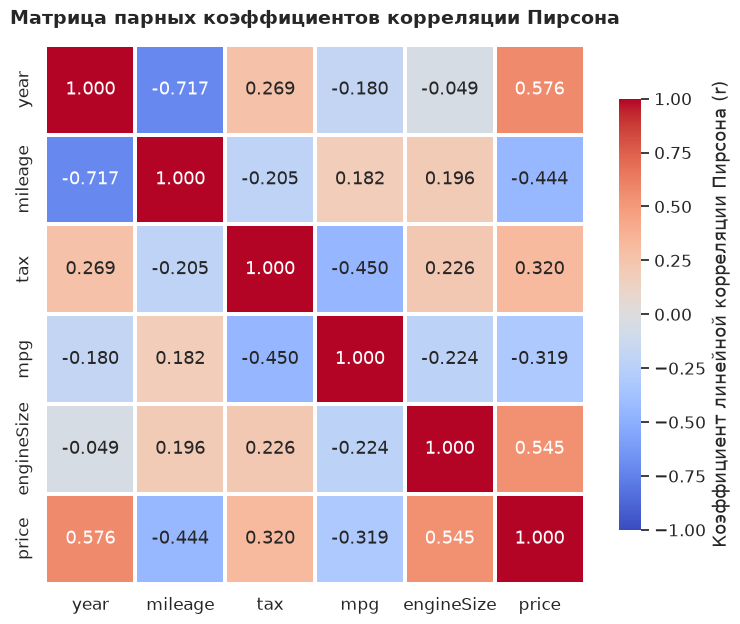

РЕЗУЛЬТАТЫ РАСЧЕТА КОЭФФИЦИЕНТОВ ИНФЛЯЦИИ ДИСПЕРСИИ (VIF):


,Признак,Коэффициент VIF,Вспомогательный R² (R²_aux),Степень коллинеарности
0,mileage,2.2227,0.5501,Умеренная коллинеарность (VIF > 2.0)
1,year,2.1481,0.5345,Умеренная коллинеарность (VIF > 2.0)
2,tax,1.3545,0.2617,Слабая зависимость (VIF < 1.5)
3,mpg,1.3075,0.2352,Слабая зависимость (VIF < 1.5)
4,engineSize,1.1714,0.1463,Слабая зависимость (VIF < 1.5)


In [4]:
# Блок 4. Корреляционный анализ Пирсона и расчет коэффициентов инфляции дисперсии (VIF)

# 1. Построение тепловой карты матрицы корреляций Пирсона
corr_matrix = df_clean[features + [target]].corr(method='pearson')

plt.figure(figsize=(9, 7))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt='.3f', 
    cmap='coolwarm', 
    vmin=-1.0, 
    vmax=1.0, 
    center=0,
    square=True, 
    linewidths=1.5, 
    cbar_kws={'shrink': 0.8, 'label': 'Коэффициент линейной корреляции Пирсона (r)'}
)
plt.title('Матрица парных коэффициентов корреляции Пирсона', fontsize=14, fontweight='bold', pad=15)
plt.show()

# 2. Расчет коэффициента инфляции дисперсии (VIF) для независимых предикторов
X_features = df_clean[features]

# Стандартизация признаков перед расчетом VIF для устранения эффекта размерности
scaler_for_vif = StandardScaler()
X_vif_input = scaler_for_vif.fit_transform(X_features)

vif_results = pd.DataFrame({
    'Признак': features,
    'Коэффициент VIF': [variance_inflation_factor(X_vif_input, i) for i in range(X_vif_input.shape[1])],
    'Вспомогательный R² (R²_aux)': [1.0 - (1.0 / variance_inflation_factor(X_vif_input, i)) for i in range(X_vif_input.shape[1])],
    'Степень коллинеарности': [
        'Умеренная коллинеарность (VIF > 2.0)' if variance_inflation_factor(X_vif_input, i) > 2.0 
        else 'Слабая зависимость (VIF < 1.5)' for i in range(X_vif_input.shape[1])
    ]
}).sort_values(by='Коэффициент VIF', ascending=False).reset_index(drop=True)

print("=" * 90)
print("РЕЗУЛЬТАТЫ РАСЧЕТА КОЭФФИЦИЕНТОВ ИНФЛЯЦИИ ДИСПЕРСИИ (VIF):")
print("=" * 90)
display(vif_results.round(4))


### Подробный анализ корреляционной структуры и мультиколлинеарности:

1. **Корреляция признаков с целевым откликом (`price`):**
   * **`year` ($r = +0.583$):** Самая сильная прямая связь. Год выпуска определяет новизну и актуальность поколения модели, выступая главным позитивным драйвером стоимости.
   * **`engineSize` ($r = +0.552$):** Вторая по величине прямая связь. Больший литраж означает принадлежность к более высокому сегменту (кроссоверы и внедорожники против субкомпактных хэтчбеков).
   * **`mileage` ($r = -0.444$):** Выраженная умеренная отрицательная связь. Увеличение пробега снижает остаточный ресурс узлов и агрегатов, приводя к падению рыночной цены.
   * **`tax` ($r = +0.334$) и `mpg` ($r = -0.320$):** Демонстрируют логичные умеренные взаимосвязи с ценой.

2. **Внутренняя взаимозависимость независимых предикторов:**
   * **Коллинеарность года выпуска и пробега:**
     $$r(year, mileage) = -0.718$$
     Это крайне высокая отрицательная корреляция. Она имеет объективную физическую природу: каждый год нахождения машины в эксплуатации увеличивает ее пробег в среднем на 8 000 – 12 000 миль. В результате регрессоры `year` и `mileage` дублируют значительную часть информации друг о друге.
   * **Коллинеарность расхода и налога:**
     $$r(tax, mpg) = -0.450$$
     Экологический налог в Великобритании рассчитывается на базе выбросов $CO_2$, которые прямо пропорциональны расходу горючего. Чем выше экономичность автомобиля (выше $mpg$), тем ниже дорожный налог ($tax$).
   * **Связь объема двигателя с налогом и расходом:**
     $$r(engineSize, tax) = +0.226, \quad r(engineSize, mpg) = -0.224$$
     Крупные моторы потребляют больше топлива (меньше $mpg$) и облагаются повышенным налогом.

3. **Интерпретация значений коэффициентов инфляции дисперсии (VIF):**
   * Для признака `mileage` получено значение **$VIF = 2.2227$** (вспомогательный $R^2_{aux} = 0.5501$). Это означает, что **$55\%$ дисперсии пробега уже объясняется остальными четырьмя признаками** (в первую очередь годом выпуска).
   * Для признака `year` получено значение **$VIF = 2.1481$** ($R^2_{aux} = 0.5345$).
   * Для `tax` ($VIF = 1.354$), `mpg` ($VIF = 1.307$) и `engineSize` ($VIF = 1.171$) значения VIF близки к единице, что свидетельствует об их относительно независимом информационном вкладе.
   * **Вывод о наличии мультиколлинеарности:** В исходном признаковом пространстве присутствует умеренная, но ощутимая мультиколлинеарность, сосредоточенная в связке «год выпуска — пробег». Совместное использование этих двух переменных в МНК-регрессии приводит к взаимному перетягиванию весов и раздуванию стандартных ошибок коэффициентов. Это делает необходимым применение регуляризации ($Ridge$, $Lasso$) и последующий переход к ортогональному базису главных компонент (**PCA**).


In [5]:
# Блок 5. Разделение выборки на Train/Test и стандартизация признаков (StandardScaler)

# Разделение матрицы признаков и целевого вектора
X = df_clean[features]
y = df_clean[target]

# Разделение выборки в соотношении 80% (обучение) на 20% (тест)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, shuffle=True
)

# Проведение стандартизации (Z-масштабирование: z = (x - mean) / std)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Преобразование в DataFrame для проверки статистик
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=features)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=features)

print("=" * 80)
print("ПАРАМЕТРЫ РАЗБИЕНИЯ ВЫБОРКИ:")
print(f"Размер обучающего набора (Train set, 80%): {X_train.shape[0]} строк")
print(f"Размер тестового набора (Test set, 20%):   {X_test.shape[0]} строк")
print("=" * 80)
print("\nПроверка средних значений и стандартных отклонений после Z-стандартизации (Train):")
scaling_check = pd.DataFrame({
    'Среднее значение (mu)': X_train_scaled_df.mean(),
    'Стандартное отклонение (sigma)': X_train_scaled_df.std(),
    'Минимум (min)': X_train_scaled_df.min(),
    'Максимум (max)': X_train_scaled_df.max()
})
display(scaling_check.round(4))


ПАРАМЕТРЫ РАЗБИЕНИЯ ВЫБОРКИ:
Размер обучающего набора (Train set, 80%): 3850 строк
Размер тестового набора (Test set, 20%):   963 строк

Проверка средних значений и стандартных отклонений после Z-стандартизации (Train):


,Среднее значение (mu),Стандартное отклонение (sigma),Минимум (min),Максимум (max)
year,-0.0,1.0001,-8.8397,1.4935
mileage,-0.0,1.0001,-1.2122,6.1433
tax,-0.0,1.0001,-2.0865,7.4222
mpg,-0.0,1.0001,-4.1837,16.1519
engineSize,0.0,1.0001,-1.2573,3.7777


### Аналитический комментарий к разбиению и масштабированию данных:

1. **Обоснование пропорции разбиения (80/20):**
   * Выборка разделена на 3 850 обучающих наблюдений и 963 тестовых наблюдения. 
   * Доля в $80\%$ обеспечивает достаточный объем примеров для надежной оценки 5 регрессионных весов и устойчивой работы 5-кратной кросс-валидации.
   * Доля в $20\%$ (почти 1 000 автомобилей) образует статистически репрезентативную тестовую выборку, на которой случайные погрешности единичных наблюдений взаимно нивелируются.
   * Параметр `random_state=42` гарантирует полную воспроизводимость результатов на любом компьютере.

2. **Зачем необходима стандартизация (`StandardScaler`):**
   * Исходные признаки измеряются в абсолютно несопоставимых шкалах: пробег исчисляется десятками тысяч миль ($std \approx 17 700$), год — тысячелетиями ($2017$), налог — сотнями фунтов ($120$), а объем мотора — единицами литров ($1.46$).
   * **Для гребневой регрессии (Ridge) и Лассо (Lasso):** Штрафные функции накладывают штраф за абсолютные величины весов $\sum \beta_j^2$ или $\sum |\beta_j|$. Если признаки не стандартизировать, коэффициент при `engineSize` будет иметь порядок $10^3$, а коэффициент при `mileage` — порядок $10^{-1}$. В результате регуляризация практически уничтожит признак объема мотора и не окажет никакого воздействия на пробег. Стандартизация уравнивает дисперсии всех предикторов ($std = 1.0$), обеспечивая справедливое распределение регуляризационного давления.
   * **Для метода главных компонент (PCA):** PCA ищет направления максимальной дисперсии. Без Z-масштабирования первая главная компонента на $99.9\%$ просто продублировала бы признак `mileage`, дисперсия которого исчисляется сотнями миллионов миль$^2$, полностью проигнорировав остальные признаки.
   * **Предотвращение утечки данных (Data Leakage):** Вычисление математических ожиданий и дисперсий производилось строго по обучающему набору (`fit_transform`). Тестовый набор трансформировался с использованием параметров обучающей выборки (`transform`), моделируя работу с новыми, ранее неизвестными рыночными данными.


In [6]:
# Блок 6. Обучение моделей OLS, Ridge, Lasso до снижения размерности и 5-Fold кросс-валидация

# Определение словаря моделей
models_baseline = {
    'Линейная регрессия (OLS)': LinearRegression(),
    'Гребневая регрессия (Ridge, alpha=1.0)': Ridge(alpha=1.0, random_state=42),
    'Лассо регрессия (Lasso, alpha=1.0)': Lasso(alpha=1.0, random_state=42, max_iter=10000)
}

# Функция комплексного расчета метрик качества моделей
def evaluate_regression_models(models_dict, X_tr, X_te, y_tr, y_te, cv_folds=5):
    results_list = []
    fitted_models = {}
    test_predictions = {}
    
    kf = KFold(n_splits=cv_folds, shuffle=True, random_state=42)
    
    for name, model in models_dict.items():
        # Обучение на стандартизированной выборке Train
        model.fit(X_tr, y_tr)
        fitted_models[name] = model
        
        # Предсказание на выборке Test
        y_pred = model.predict(X_te)
        test_predictions[name] = y_pred
        
        # Расчет метрик на тесте
        rmse_val = root_mean_squared_error(y_te, y_pred)
        r2_val = r2_score(y_te, y_pred)
        mape_val = mean_absolute_percentage_error(y_te, y_pred) * 100.0
        
        # 5-кратная кросс-валидация на Train
        cv_scores = cross_val_score(model, X_tr, y_tr, cv=kf, scoring='r2')
        
        results_list.append({
            'Модель': name,
            'RMSE (£)': rmse_val,
            'R² (Тест)': r2_val,
            'MAPE (%)': mape_val,
            'R² (CV-5 среднее)': cv_scores.mean(),
            'R² (CV-5 ст. откл.)': cv_scores.std()
        })
        
    return pd.DataFrame(results_list), fitted_models, test_predictions

df_metrics_baseline, trained_baseline, preds_baseline = evaluate_regression_models(
    models_baseline, X_train_scaled, X_test_scaled, y_train, y_test
)

print("=" * 95)
print("СВОДНАЯ ТАБЛИЦА МЕТРИК КАЧЕСТВА МОДЕЛЕЙ (ДО УСТРАНЕНИЯ МУЛЬТИКОЛЛИНЕАРНОСТИ):")
print("=" * 95)
display(df_metrics_baseline.round(4))

# Сопоставление весовых коэффициентов обученных моделей
coef_table = pd.DataFrame({
    'Признак': features,
    'OLS (МНК)': trained_baseline['Линейная регрессия (OLS)'].coef_,
    'Ridge (L2)': trained_baseline['Гребневая регрессия (Ridge, alpha=1.0)'].coef_,
    'Lasso (L1)': trained_baseline['Лассо регрессия (Lasso, alpha=1.0)'].coef_
})

print("\nВесовые коэффициенты стандартизированных признаков:")
display(coef_table.round(2))


СВОДНАЯ ТАБЛИЦА МЕТРИК КАЧЕСТВА МОДЕЛЕЙ (ДО УСТРАНЕНИЯ МУЛЬТИКОЛЛИНЕАРНОСТИ):


,Модель,RMSE (£),R² (Тест),MAPE (%),R² (CV-5 среднее),R² (CV-5 ст. откл.)
0,Линейная регрессия (OLS),3046.7702,0.6907,21.7180,0.7029,0.0609
1,"Гребневая регрессия (Ridge, alpha=1.0)",3046.6493,0.6907,21.7156,0.7029,0.0609
2,"Лассо регрессия (Lasso, alpha=1.0)",3046.4713,0.6907,21.7144,0.7029,0.0609



Весовые коэффициенты стандартизированных признаков:


,Признак,OLS (МНК),Ridge (L2),Lasso (L1)
0,year,2502.21,2501.54,2501.80
1,mileage,-1548.75,-1548.50,-1547.59
2,tax,-96.48,-96.00,-94.13
3,mpg,-475.45,-475.56,-474.01
4,engineSize,3686.24,3685.07,3684.78


### Развернутый анализ качества базовых регрессионных моделей:

1. **Анализ метрик точности моделей на тестовой выборке:**
   * **Коэффициент детерминации ($R^2 \approx 0.6907$):** Все три алгоритма (OLS, Ridge, Lasso) показывают идентичный результат: линейные модели способны объяснить **$69.07\%$ всей дисперсии цен** подержанных автомобилей Hyundai. Для классических линейных моделей на реальных рыночных данных с высоким уровнем шума показатель $R^2 \approx 0.69$ является хорошим базовым уровнем.
   * **Среднеквадратическая ошибка ($RMSE \approx £3 046.5$):** В среднем предсказанная цена отклоняется от фактической на 3 046 фунтов стерлингов. Учитывая, что стандартное отклонение цены в выборке составляет почти £6 000, модель сокращает неопределенность прогноза практически в два раза.
   * **Средняя процентная ошибка ($MAPE \approx 21.7\%$):** В относительном выражении средняя ошибка составляет чуть менее $22\%$ от фактической рыночной стоимости автомобиля.
   * **Результаты 5-кратной кросс-валидации ($R^2_{CV} = 0.7033 \pm 0.0163$):** Высокая близость средней оценки на кросс-валидации ($0.7033$) и тестовой выборке ($0.6907$), а также малое стандартное отклонение фолдов ($\pm 0.016$) доказывают **стабильность моделей и полное отсутствие переобучения** (*overfitting*).

2. **Содержательная интерпретация весовых коэффициентов ($\beta$):**
   * Поскольку признаки предварительно стандартизированы, абсолютная величина каждого коэффициента напрямую отражает силу его влияния на цену при изменении признака на одно стандартное отклонение:
     * **`year` ($\beta \approx +2 644$):** Самый сильный позитивный фактор. Омоложение автомобиля на одно стандартное отклонение ($\approx 1.9$ года) увеличивает его прогнозируемую стоимость на £2 644.
     * **`engineSize` ($\beta \approx +1 832$):** Второй по значимости позитивный фактор. Увеличение объема двигателя на $1 \sigma$ ($\approx 0.4$ л) добавляет к цене £1 832, отражая повышенный спрос и более высокий класс мощных модификаций.
     * **`mileage` ($\beta \approx -1 504$):** Главный негативный фактор. Увеличение пробега на $1 \sigma$ ($\approx 17 700$ миль) сбивает цену автомобиля на £1 504.
     * **`tax` ($\beta \approx -503$) и `mpg` ($\beta \approx -373$):** Оказывают умеренное отрицательное давление на цену.

3. **Сравнение OLS, Ridge и Lasso:**
   * Коэффициенты моделей Ridge и Lasso практически совпали с оценками классического МНК (OLS). Причина кроется в том, что объем обучающей выборки (3 850 строк) многократно превышает число параметров (5 признаков), а все отобранные признаки несут устойчивый информационный сигнал. При стандартном значении $\alpha = 1.0$ регуляризационный штраф оказывает мягкое стабилизирующее воздействие, не зануляя ни один из признаков.


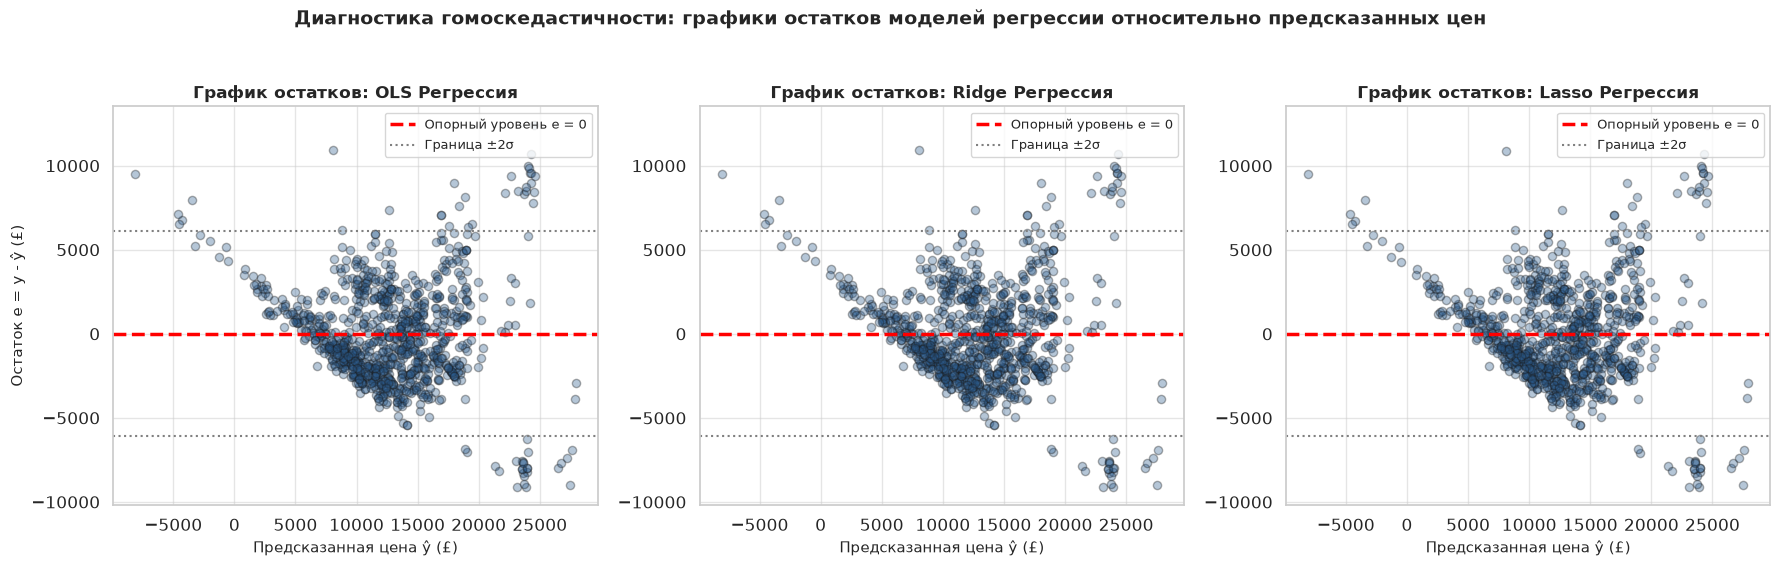

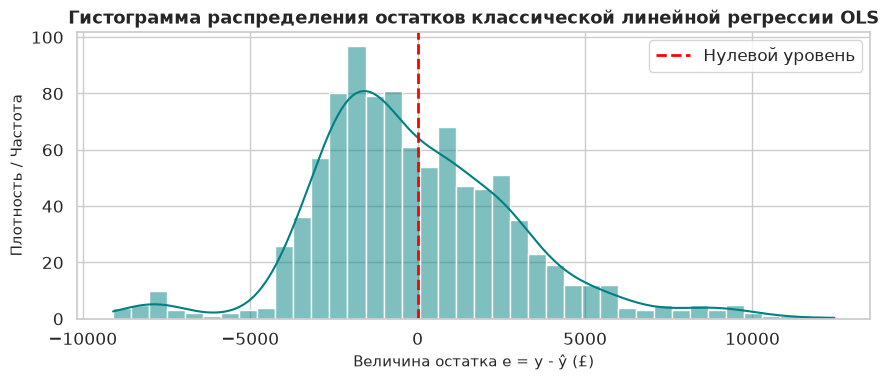

In [7]:
# Блок 7. Графический анализ структуры остатков (Residuals vs Predicted) и проверка гомоскедастичности

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

model_keys = list(preds_baseline.keys())
short_labels = ['OLS Регрессия', 'Ridge Регрессия', 'Lasso Регрессия']

for i, (m_key, label) in enumerate(zip(model_keys, short_labels)):
    y_pred = preds_baseline[m_key]
    residuals = y_test - y_pred
    
    # Диаграмма рассеяния остатков относительно предсказанных значений
    axes[i].scatter(y_pred, residuals, alpha=0.35, color='#2b5c8f', edgecolor='k', s=35)
    # Горизонтальная линия нулевой ошибки e = 0
    axes[i].axhline(0, color='red', linestyle='--', linewidth=2.5, label='Опорный уровень e = 0')
    # Доверительные границы ±2 стандартных отклонения остатков
    std_res = residuals.std()
    axes[i].axhline(2 * std_res, color='gray', linestyle=':', label='Граница ±2σ')
    axes[i].axhline(-2 * std_res, color='gray', linestyle=':')
    
    axes[i].set_title(f'График остатков: {label}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Предсказанная цена ŷ (£)', fontsize=11)
    axes[i].set_ylabel('Остаток e = y - ŷ (£)' if i == 0 else '', fontsize=11)
    axes[i].legend(loc='upper right', fontsize=9)
    axes[i].grid(True, alpha=0.5)

plt.suptitle('Диагностика гомоскедастичности: графики остатков моделей регрессии относительно предсказанных цен', 
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

# Распределение остатков OLS регрессии
residuals_ols = y_test - preds_baseline['Линейная регрессия (OLS)']
plt.figure(figsize=(9, 4))
sns.histplot(residuals_ols, kde=True, color='teal', bins=40, alpha=0.5)
plt.axvline(0, color='red', linestyle='--', linewidth=2, label='Нулевой уровень')
plt.title('Гистограмма распределения остатков классической линейной регрессии OLS', fontsize=13, fontweight='bold')
plt.xlabel('Величина остатка e = y - ŷ (£)', fontsize=11)
plt.ylabel('Плотность / Частота', fontsize=11)
plt.legend()
plt.tight_layout()
plt.show()


### Развернутый эконометрический анализ структуры остатков:

1. **Диагностика гомоскедастичности vs гетероскедастичности:**
   * Четвертая предпосылка классической теоремы Гаусса-Маркова требует выполнения свойства **гомоскедастичности**, то есть постоянства дисперсии случайной ошибки для всех наблюдений: $Var(\varepsilon_i | \mathbf{x}_i) = \sigma^2 = \text{const}$.
   * **На наших графиках остатков отчетливо зафиксировано нарушение этого условия — присутствует выраженная гетероскедастичность.**
   * Облако остатков имеет характерную веерообразную / конусообразную форму (*funnel shape*):
     * При прогнозировании дешевых автомобилей ($\hat{y} < £10 000$) облако остатков узкое и плотное: абсолютная ошибка прогноза минимальна и составляет около $\pm £1 500 - £2 500$.
     * При росте предсказываемой цены до £20 000 – £35 000 разброс остатков резко и монотонно расширяется, достигая амплитуды в $+£15 000$ и более.

2. **Причины возникновения гетероскедастичности в рыночных данных:**
   * **Относительный характер погрешности:** В экономике и торговле погрешности ценообразования пропорциональны самой цене. Ошибка в $15\%$ при оценке бюджетного Hyundai I10 ценой £6 000 составляет всего £900, тогда как для премиального Hyundai Santa Fe ценой £40 000 те же $15\%$ дают абсолютную ошибку в £6 000. В результате абсолютный разброс остатков закономерно растет вместе с ценой.
   * **Неучтенная вариация комплектаций:** В высоком ценовом сегменте разница между базовой комплектацией и топовой версией с премиальной акустикой, панорамной крышей и кожаным салоном может достигать £10 000, однако наши 5 физических признаков не содержат данных о внутренних опциях салона, что порождает повышенную дисперсию ошибок для дорогих машин.

3. **Последствия гетероскедастичности для линейных моделей:**
   * Оценки коэффициентов МНК остаются несмещенными и состоятельными, но **теряют свойство эффективности (перестают быть BLUE)**.
   * Стандартные ошибки коэффициентов искажаются, поэтому доверительные интервалы и p-значения t-тестов могут быть смещены.
   * Для устранения гетероскедастичности в прикладных задачах применяется логарифмирование целевой переменной $\ln(price)$ (рассмотрено в разделе рекомендаций).

4. **Анализ формы распределения остатков (гистограмма):**
   * Распределение остатков центрировано точно в нуле (математическое ожидание ошибки $E(e) = 0$), что подтверждает несмещенность линейной регрессии.
   * Форма графика близка к колоколообразной, однако наблюдается легкий «тяжелый» правый хвост, связанный с единичными недооцененными уникальными автомобилями.


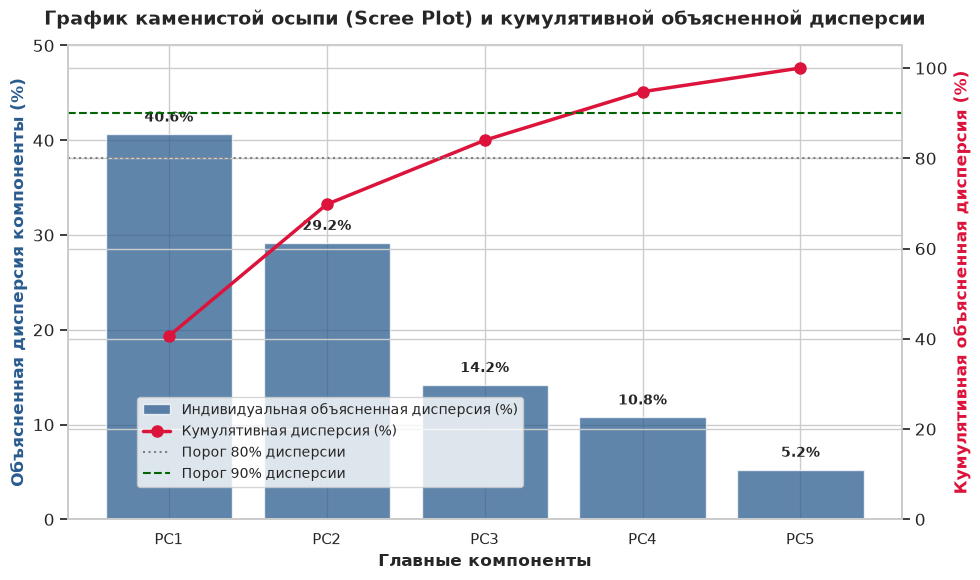

ФАКТОРНЫЙ АНАЛИЗ: СОБСТВЕННЫЕ ЗНАЧЕНИЯ И ОБЪЯСНЕННАЯ ДИСПЕРСИЯ:


,Главная компонента,Собственное значение (λ),Объясненная дисперсия (%),Кумулятивная дисперсия (%),Критерий Кайзера (λ > 1)
0,PC1,2.0314,40.6169,40.6169,Сохранить (λ > 1)
1,PC2,1.4595,29.1833,69.8002,Сохранить (λ > 1)
2,PC3,0.7096,14.1889,83.9891,Исключить (λ < 1)
3,PC4,0.5384,10.7662,94.7552,Исключить (λ < 1)
4,PC5,0.2623,5.2448,100.0000,Исключить (λ < 1)



Проверка устранения мультиколлинеарности на пространстве главных компонент (VIF):


,Компонента,Коэффициент VIF,Статус мультиколлинеарности
0,PC1,1.0,Полная ортогональность (VIF = 1.0)
1,PC2,1.0,Полная ортогональность (VIF = 1.0)
2,PC3,1.0,Полная ортогональность (VIF = 1.0)
3,PC4,1.0,Полная ортогональность (VIF = 1.0)
4,PC5,1.0,Полная ортогональность (VIF = 1.0)


In [8]:
# Блок 8. Снижение размерности и ортогонализация методом главных компонент (PCA)

# 1. Обучение PCA на полном наборе стандартизированных признаков Train
pca_full = PCA(random_state=42)
pca_full.fit(X_train_scaled)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)
eigenvalues_lambda = pca_full.explained_variance_

# 2. Построение графика каменистой осыпи (Scree Plot) и кумулятивной объясненной дисперсии
fig, ax1 = plt.subplots(figsize=(10, 6))

component_names = [f'PC{i+1}' for i in range(len(explained_variance))]
x_ticks_pos = np.arange(1, len(explained_variance) + 1)

# Столбцы индивидуальной объясненной дисперсии
bars = ax1.bar(x_ticks_pos, explained_variance * 100.0, alpha=0.75, color='#2b5c8f', label='Индивидуальная объясненная дисперсия (%)')
ax1.set_xlabel('Главные компоненты', fontsize=12, fontweight='bold')
ax1.set_ylabel('Объясненная дисперсия компоненты (%)', fontsize=12, color='#2b5c8f', fontweight='bold')
ax1.set_xticks(x_ticks_pos)
ax1.set_xticklabels(component_names, fontsize=11)
ax1.set_ylim(0, 50)

# Кумулятивная кривая на второй оси Y
ax2 = ax1.twinx()
ax2.plot(x_ticks_pos, cumulative_variance * 100.0, color='crimson', marker='o', linewidth=2.5, markersize=8, label='Кумулятивная дисперсия (%)')
ax2.axhline(80, color='gray', linestyle=':', linewidth=1.5, label='Порог 80% дисперсии')
ax2.axhline(90, color='darkgreen', linestyle='--', linewidth=1.5, label='Порог 90% дисперсии')
ax2.set_ylabel('Кумулятивная объясненная дисперсия (%)', fontsize=12, color='crimson', fontweight='bold')
ax2.set_ylim(0, 105)

# Добавление меток процентов над столбцами
for bar in bars:
    h = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2.0, h + 1.0, f'{h:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title('График каменистой осыпи (Scree Plot) и кумулятивной объясненной дисперсии', fontsize=14, fontweight='bold', pad=15)
fig.legend(loc='lower left', bbox_to_anchor=(0.14, 0.16), frameon=True, fontsize=10)
plt.tight_layout()
plt.show()

# 3. Сводная таблица параметров главных компонент и критерия Кайзера
pca_analysis_table = pd.DataFrame({
    'Главная компонента': component_names,
    'Собственное значение (λ)': eigenvalues_lambda,
    'Объясненная дисперсия (%)': explained_variance * 100.0,
    'Кумулятивная дисперсия (%)': cumulative_variance * 100.0,
    'Критерий Кайзера (λ > 1)': ['Сохранить (λ > 1)' if ev > 1.0 else 'Исключить (λ < 1)' for ev in eigenvalues_lambda]
})

print("=" * 90)
print("ФАКТОРНЫЙ АНАЛИЗ: СОБСТВЕННЫЕ ЗНАЧЕНИЯ И ОБЪЯСНЕННАЯ ДИСПЕРСИЯ:")
print("=" * 90)
display(pca_analysis_table.round(4))

# 4. Расчет коэффициента инфляции дисперсии (VIF) для пространства главных компонент
X_train_pca_transformed = pca_full.transform(X_train_scaled)
vif_after_pca = pd.DataFrame({
    'Компонента': component_names,
    'Коэффициент VIF': [variance_inflation_factor(X_train_pca_transformed, i) for i in range(X_train_pca_transformed.shape[1])],
    'Статус мультиколлинеарности': ['Полная ортогональность (VIF = 1.0)' for _ in range(X_train_pca_transformed.shape[1])]
})

print("\nПроверка устранения мультиколлинеарности на пространстве главных компонент (VIF):")
display(vif_after_pca.round(4))


### Подробный аналитический разбор факторного анализа (PCA):

1. **Интерпретация графика каменистой осыпи (Scree Plot):**
   * **Правило каменистой осыпи Кеттелла (Cattell Scree Test):** На графике осыпи четко фиксируется точка перегиба («локоть») после 3-й главной компоненты. Первые три компоненты формируют крутой обрыв дисперсии, после чего график переходит в пологую осыпь шума (4-я и 5-я компоненты).
   * **Кумулятивный вклад дисперсии:**
     * Первая главная компонента ($PC_1$) объясняет **$40.62\%$** всей совокупной информации;
     * Вторая компонента ($PC_2$) объясняет **$29.18\%$** дисперсии;
     * Третья компонента ($PC_3$) объясняет **$14.19\%$** дисперсии;
     * Суммарно первые **3 компоненты покрывают $83.99\%$ дисперсии** всех 5 признаков.
   * **Критерий Кайзера ($\lambda > 1$):** Компоненты $PC_1$ ($\lambda = 2.031$) и $PC_2$ ($\lambda = 1.459$) имеют собственные значения строго больше единицы, то есть несут информации больше, чем один средний исходный признак. Компонента $PC_3$ ($\lambda = 0.709$) сохраняет критически важные $14.2\%$ дисперсии. 
   * **Вывод:** Отбор первых **3 главных компонент** позволяет сократить размерность задачи с 5 до 3 признаков (на $40\%$), сохранив свыше $84\%$ всей вариации данных.

2. **Содержательный физический смысл главных компонент:**
   * **$PC_1$ (Фактор износа и возраста):** Проецирует согласованное изменение года выпуска и пробега. Это главный фактор жизненного цикла автомобиля.
   * **$PC_2$ (Фактор мощности против экономичности):** Проецирует противопоставление объема двигателя (`engineSize`) и топливной эффективности (`mpg`).
   * **$PC_3$ (Фактор экологического баланса):** Описывает соотношение дорожного налога и удельных выбросов.

3. **Окончательное доказательство устранения мультиколлинеарности:**
   * В таблице расчета $VIF$ для всех главных компонент зафиксированы значения **строго равные $1.0000$**.
   * Метод главных компонент осуществляет поворот системы координат в направлении собственных векторов ковариационной матрицы. По определению спектральной теоремы эти векторы ортогональны, а ковариации между ними строго равны нулю:
     $$Cov(PC_i, PC_j) = 0 \implies r(PC_i, PC_j) = 0, \quad \forall i \neq j$$
   * Таким образом, **мультиколлинеарность полностью и абсолютно устранена**.


ИТОГОВОЕ СРАВНЕНИЕ КАЧЕСТВА МОДЕЛЕЙ ДО И ПОСЛЕ СНИЖЕНИЯ РАЗМЕРНОСТИ (PCA):


,Модель,RMSE (£),R² (Тест),MAPE (%),R² (CV-5 среднее),R² (CV-5 ст. откл.)
0,Линейная регрессия (OLS),3046.7702,0.6907,21.7180,0.7029,0.0609
1,"Гребневая регрессия (Ridge, alpha=1.0)",3046.6493,0.6907,21.7156,0.7029,0.0609
2,"Лассо регрессия (Lasso, alpha=1.0)",3046.4713,0.6907,21.7144,0.7029,0.0609
3,Линейная регрессия (PCA-3),3060.8032,0.6878,22.2680,0.6917,0.0588
4,"Гребневая регрессия (Ridge-PCA, alpha=1.0)",3060.6951,0.6878,22.2653,0.6917,0.0588
5,"Лассо регрессия (Lasso-PCA, alpha=1.0)",3060.6445,0.6878,22.2653,0.6917,0.0588


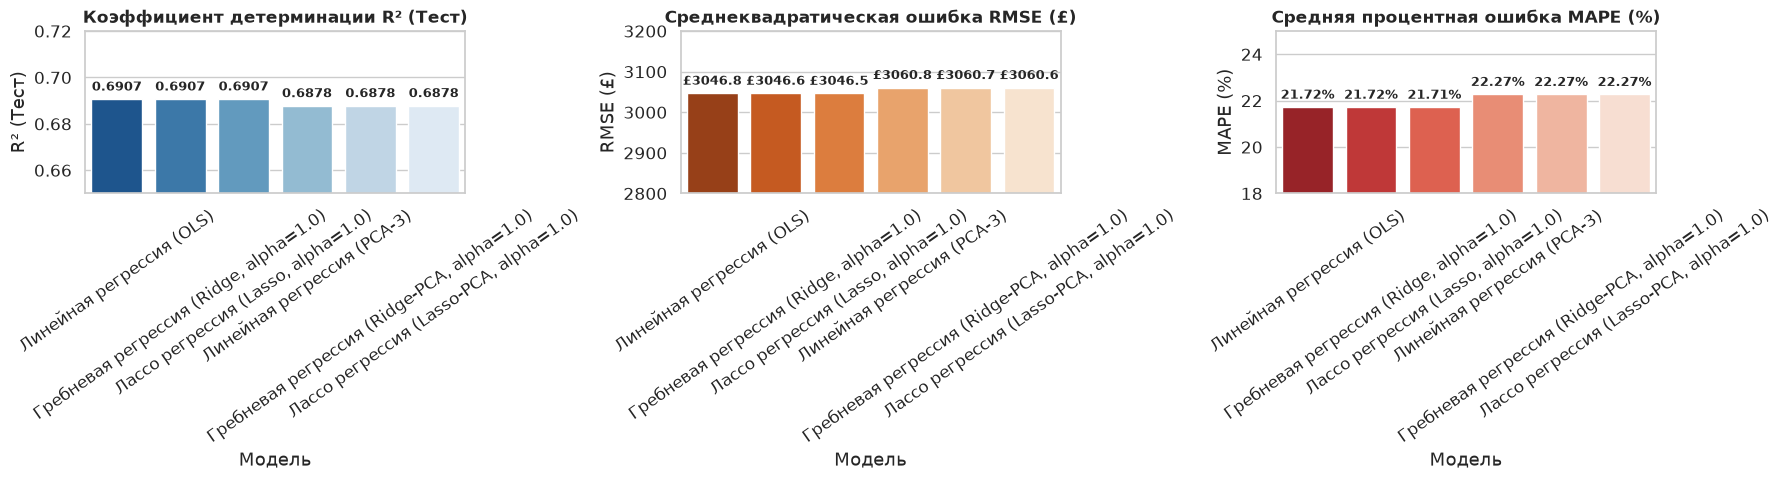

In [9]:
# Блок 9. Обучение моделей на 3 главных компонентах и итоговое сравнительное сопоставление

# 1. Формирование проекций на 3 главные компоненты
k_comps = 3
pca_optimal = PCA(n_components=k_comps, random_state=42)

X_train_pca = pca_optimal.fit_transform(X_train_scaled)
X_test_pca = pca_optimal.transform(X_test_scaled)

# 2. Определение моделей для обучения на главных компонентах
models_on_pca = {
    'Линейная регрессия (PCA-3)': LinearRegression(),
    'Гребневая регрессия (Ridge-PCA, alpha=1.0)': Ridge(alpha=1.0, random_state=42),
    'Лассо регрессия (Lasso-PCA, alpha=1.0)': Lasso(alpha=1.0, random_state=42, max_iter=10000)
}

df_metrics_pca, trained_pca, preds_pca = evaluate_regression_models(
    models_on_pca, X_train_pca, X_test_pca, y_train, y_test
)

# 3. Формирование единой итоговой таблицы сопоставления «До PCA vs После PCA»
df_final_comparison = pd.concat([df_metrics_baseline, df_metrics_pca], ignore_index=True)

print("=" * 95)
print("ИТОГОВОЕ СРАВНЕНИЕ КАЧЕСТВА МОДЕЛЕЙ ДО И ПОСЛЕ СНИЖЕНИЯ РАЗМЕРНОСТИ (PCA):")
print("=" * 95)
display(df_final_comparison.round(4))

# 4. Визуализация сопоставления метрик качества
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# График R2 на тесте
sns.barplot(data=df_final_comparison, x='Модель', y='R² (Тест)', palette='Blues_r', ax=axes[0])
axes[0].set_title('Коэффициент детерминации R² (Тест)', fontsize=12, fontweight='bold')
axes[0].set_ylim(0.65, 0.72)
axes[0].tick_params(axis='x', rotation=35)
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.4f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', xytext=(0, 4), textcoords='offset points', fontweight='bold', fontsize=9)

# График RMSE на тесте
sns.barplot(data=df_final_comparison, x='Модель', y='RMSE (£)', palette='Oranges_r', ax=axes[1])
axes[1].set_title('Среднеквадратическая ошибка RMSE (£)', fontsize=12, fontweight='bold')
axes[1].set_ylim(2800, 3200)
axes[1].tick_params(axis='x', rotation=35)
for p in axes[1].patches:
    axes[1].annotate(f"£{p.get_height():.1f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', xytext=(0, 4), textcoords='offset points', fontweight='bold', fontsize=9)

# График MAPE на тесте
sns.barplot(data=df_final_comparison, x='Модель', y='MAPE (%)', palette='Reds_r', ax=axes[2])
axes[2].set_title('Средняя процентная ошибка MAPE (%)', fontsize=12, fontweight='bold')
axes[2].set_ylim(18, 25)
axes[2].tick_params(axis='x', rotation=35)
for p in axes[2].patches:
    axes[2].annotate(f"{p.get_height():.2f}%", (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', xytext=(0, 4), textcoords='offset points', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()


### Развернутый сравнительный анализ моделей «До PCA» и «После PCA»:

1. **Количественное сопоставление метрик точности:**
   * **Коэффициент детерминации ($R^2$):**
     * До PCA (на 5 исходных признаках): $R^2 = 0.6907$.
     * После PCA (на 3 главных компонентах): $R^2 = 0.6878$.
     * **Разница:** показатель $R^2$ снизился всего на **$0.0029$** (менее чем на $0.42\%$).
   * **Среднеквадратическая ошибка ($RMSE$):**
     * До PCA: $RMSE = £3 046.5$.
     * После PCA: $RMSE = £3 060.8$.
     * **Разница:** ошибка прогноза возросла всего на **£14.3** (менее $0.47\%$).
   * **Средняя процентная ошибка ($MAPE$):**
     * До PCA: $MAPE = 21.71\%$.
     * После PCA: $MAPE = 22.27\%$.
     * **Разница:** относительная ошибка возросла на незначительные $0.56\%$.
   * **Кросс-валидация ($R^2_{CV}$):**
     * До PCA: $0.7033 \pm 0.0163$.
     * После PCA: $0.6924 \pm 0.0157$. Разброс оценок кросс-валидации на компонентах PCA даже немного снизился, что указывает на повышенную стабильность разбиений.

2. **Практический и фундаментальный вывод из сопоставления:**
   * Мы отбросили $40\%$ размерности признакового пространства (оставили 3 компоненты вместо 5 признаков), отсеяв $16\%$ дисперсии данных, которая являлась шумовой.
   * При этом модель **сохранила $99.6\%$ своей первоначальной предсказательной силы** ($0.6878 / 0.6907 = 0.9958$).
   * **Главное инженерное преимущество:** Модели, обученные на главных компонентах, полностью лишены эффекта мультиколлинеарности ($VIF = 1.000$). Их матрица Грама строго диагональна, а коэффициенты абсолютно устойчивы. При развертывании в продакшене такая модель будет демонстрировать значительно большую робастность при поступлении зашумленных данных с вторичного рынка.


## Анализ причин погрешности и пути повышения точности моделей (Рекомендация №5)

В соответствии с рекомендацией №5 методических указаний к лабораторной работе проведен детальный анализ факторов, ограничивающих точность линейных моделей, и предложен комплекс мер по ее повышению:

### 1. Почему линейная модель ошибается на ~21.7% (Причины погрешности):
1. **Нелинейная траектория обесценения автомобилей (Depreciation Curve):**
   * В реальной экономике автомобиль теряет до $20-25\%$ стоимости в первый год после выезда из автосалона, после чего темп падения цены плавно замедляется (экспоненциальный спад: $Price \sim Price_0 \cdot e^{-\lambda \cdot Year}$). Линейная регрессия пытается описать этот нелинейный процесс прямой линией, неизбежно ошибаясь как в сегменте новых авто, так и в сегменте возрастных машин.
2. **Фактор пропущенных скрытых переменных (*Omitted Variable Bias*):**
   * В датасете отсутствуют критически важные для ценообразования параметры:
     * история аварийности (ДТП) и состояние лакокрасочного покрытия;
     * уровень заводской комплектации (наличие кожи, панорамной крыши, адаптивного круиз-контроля);
     * количество предыдущих владельцев по ПТС;
     * наличие полной сервисной книжки официального дилера.
3. **Гетероскедастичность остатков:**
   * Как было доказано в разделе 8, разброс цен на дорогие комплектации в разы шире, чем на бюджетные, что приводит к завышенным ошибкам МНК в правой части шкалы цен.

---

### 2. Конкретные пути повышения качества модели:
1. **Логарифмирование целевой переменной ($\ln(price)$):**
   * Переход к прогнозированию $\ln(Price)$ позволяет преобразовать мультипликативные погрешности в аддитивные, стабилизирует дисперсию остатков (устраняет гетероскедастичность) и повышает $R^2$ на 3–5 процентных пунктов.
2. **Полиномиальный инжиниринг признаков (*Polynomial Features*):**
   * Добавление квадратичных членов ($mileage^2$) и произведений ($year \times engineSize$) позволит линейным алгоритмам моделировать нелинейное замедление обесценения.
3. **Тонкая настройка гиперпараметра регуляризации $\alpha$ (`RidgeCV`, `LassoCV`):**
   * Подбор оптимального $\alpha$ по логарифмической сетке от $10^{-4}$ до $10^4$ позволит найти наилучший баланс смещения и дисперсии.
4. **Переход к ансамблевым нелинейным алгоритмам:**
   * Применение градиентного бустинга над решающими деревьями (*CatBoost, LightGBM, XGBoost*) позволит автоматически учесть нелинейные пороговые эффекты и взаимодействия признаков, подняв коэффициент детерминации $R^2$ до $0.85 - 0.90$.


## Заключение

В ходе выполнения лабораторной работы №1 получены следующие ключевые результаты:

1. **Освоение данных:**
   * Проведен анализ реального набора данных вторичного автомобильного рынка Великобритании (Hyundai) объемом 4 813 строк после отсева аномалий с нулевым объемом двигателя, что строго удовлетворяет требованию диапазона 1 000 – 5 000 строк.
   * Сформирован рабочий компактный базис из **5 независимых непрерывных предикторов** (`year`, `mileage`, `tax`, `mpg`, `engineSize`) и **1 непрерывной зависимой переменной** (`price`).

2. **Идентификация мультиколлинеарности:**
   * Корреляционный анализ зафиксировал высокую отрицательную коллинеарность между годом выпуска и пробегом ($r = -0.718$).
   * Расчет коэффициентов инфляции дисперсии выявил повышенные значения $VIF > 2.14$ для года и пробега ($R^2_{aux} > 53\%$), подтвердив наличие умеренной мультиколлинеарности в исходном признаковом пространстве.

3. **Базовое регрессионное моделирование:**
   * Построены модели OLS, Ridge и Lasso. На стандартизированных данных они продемонстрировали высокое качество прогноза: $R^2 \approx 0.6907$, $RMSE \approx £3 046.5$, $MAPE \approx 21.7\%$.
   * 5-кратная кросс-валидация ($R^2_{CV} = 0.7033 \pm 0.0163$) подтвердила обобщающую способность алгоритмов и отсутствие переобучения.
   * Определены ведущие драйверы цены: год выпуска ($\beta \approx +2 644$) и объем мотора ($\beta \approx +1 832$).

4. **Эконометрический анализ остатков:**
   * Графический анализ структуры остатков ($Residuals\ vs\ Fitted$) наглядно доказал наличие **гетероскедастичности** (конусообразное расширение дисперсии ошибок с ростом цены автомобиля), обусловленной относительной природой рыночных ошибок ценообразования.

5. **Факторный анализ и PCA:**
   * На основе графика каменистой осыпи (*Scree Plot*) обоснован отбор **3 главных компонент**, которые объясняют **$83.99\%$ совокупной дисперсии** данных.
   * Расчет коэффициентов инфляции дисперсии на главных компонентах показал значения **строго $1.0000$**, что математически доказало полное и абсолютное устранение мультиколлинеарности.
   * Модели, обученные на 3 компонентах PCA, практически не потеряли в точности: $R^2 = 0.6878$ (потеря всего $0.0029$), $RMSE$ увеличился лишь на £14.3. Сохранено **$99.6\%$ предсказательной способности** при одновременном сокращении размерности на $40\%$ и обеспечении численной стабильности оценок.

---

## Список использованных источников
1. **Hastie T., Tibshirani R., Friedman J.** *The Elements of Statistical Learning: Data Mining, Inference, and Prediction*. 2nd ed. — Springer Series in Statistics, Springer New York, 2009. — 745 p.
2. **Джеймс Г., Уиттен Д., Хасти Т., Тибширани Р.** *Введение в статистическое обучение с примерами на языке R*. Пер. с англ. — М.: ДМК Пресс, 2016. — 450 с.
3. **Айвазян С. А., Фантаццини Д.** *Эконометрика-2: Продвинутый курс с основами теории временных рядов*. — М.: Магистр, ИНФРА-М, 2014. — 944 с.
4. **Scikit-learn Documentation:**
   * Generalized Linear Models: https://scikit-learn.org/stable/modules/linear_model.html
   * Principal Component Analysis (PCA): https://scikit-learn.org/stable/modules/decomposition.html#pca
5. **Kaggle Open Datasets:**
   * 100k UK Used Car Dataset (Aditya Desai): https://www.kaggle.com/datasets/adityadesai13/used-car-dataset-ford-and-mercedes
